In [68]:
from prepare_quarterly import prepare_quarterly_boroughs
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [69]:
df_month = prepare_quarterly_boroughs()

month
95.0    1566
87.0    1555
90.0    1540
86.0    1490
94.0    1465
91.0    1411
93.0    1410
96.0    1370
88.0    1357
89.0    1285
92.0    1266
85.0    1033
Name: count, dtype: int64


/Users/josh/Library/CloudStorage/GoogleDrive-jeverer@gmail.com/My Drive/London Sport/london_sport2/src/stream_1/quarterly/prepare_quarterly.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw['LA_Name'] = raw['LA_2023'].map(dc.get_data_dict()['LA_2023']['value_labels'])


In [70]:
df_month.shape

(2687, 7)

In [71]:
df_month['t'] = df_month.groupby('LA_Name').cumcount()

In [72]:
df_month[['LA_Name', 't']]

,LA_Name,t
0,Barking and Dagenham,0
1,Barking and Dagenham,1
2,Barking and Dagenham,2
3,Barking and Dagenham,3
4,Barking and Dagenham,4
...,...,...
2765,Westminster,79
2766,Westminster,80
2767,Westminster,81
2768,Westminster,82


In [73]:
train = df_month[df_month['t'] < 84]
test = df_month[df_month['t'] >= 84]
test.shape

(0, 8)

In [74]:
df_covid = df_month.groupby('t')['MEMS7_ALL'].mean().reset_index()
#df_covid['label'] = ['17','','','','18','','','','19','','','','20','','','','21','','','','22','','','', '23', '', '', '', '24']

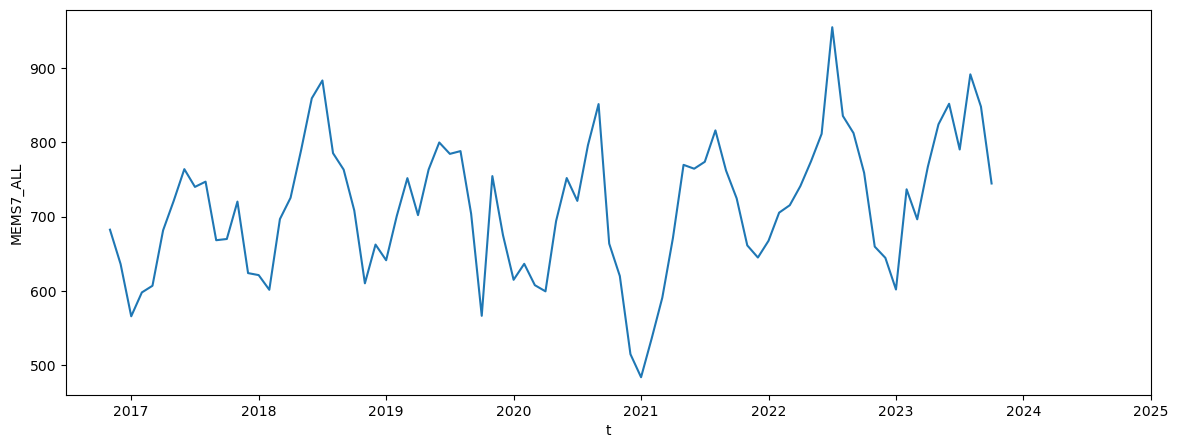

In [75]:

plt.figure(figsize=(14, 5))
sns.lineplot(data=df_covid, x='t', y='MEMS7_ALL')
plt.xticks(ticks=[2, 14, 26, 38, 50, 62, 74, 86, 98], labels=['2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'])
plt.show()


In [76]:
model = SARIMAX(df_covid['MEMS7_ALL'], order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()
forecast_values = results.forecast(60).values
df_covid_forecast = pd.DataFrame({'t': range(84, 144), 'MEMS7_ALL': forecast_values, 'type': 'forecast'})
df_covid['type'] = 'historical'

df_covid = pd.concat([df_covid, df_covid_forecast], ignore_index=True)

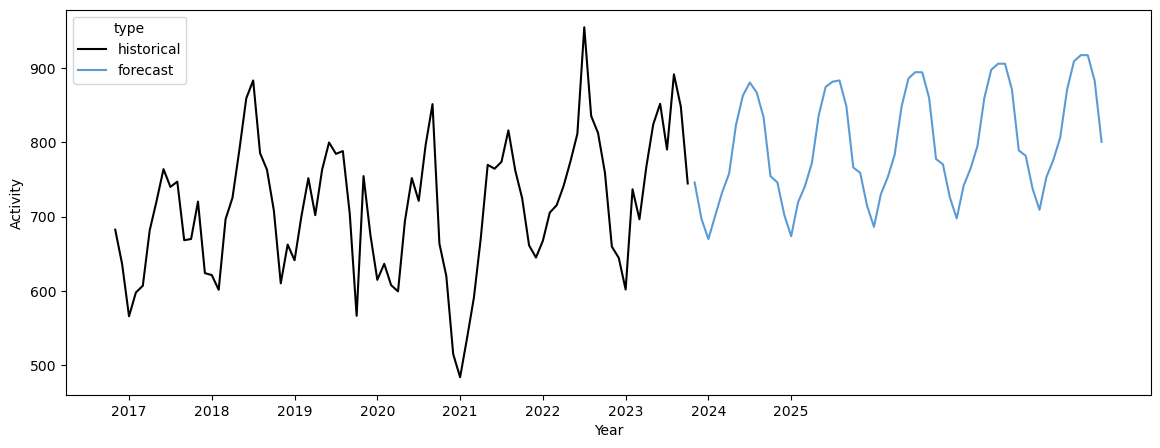

In [77]:
year_map = {0:'2017', 4:'2018', 8:'2019', 12:'2020', 16:'2021', 20:'2022', 24:'2023', 28:'2024', 32:'2025', 36:'2026'}
plt.figure(figsize=(14, 5))
g = sns.lineplot(data=df_covid, x='t', y='MEMS7_ALL', hue='type', palette={'historical': 'black', 'forecast': '#5B9BD5'})
plt.xticks(ticks=[2, 14, 26, 38, 50, 62, 74, 86, 98], labels=['2017','2018','2019','2020','2021','2022','2023','2024','2025'])
g.set(xlabel='Year', ylabel='Activity')
plt.show()

In [78]:
results = []

for borough in train.LA_Name.unique():
    X_train = train[train['LA_Name'] == borough]['t']
    y_train = train[train['LA_Name'] == borough]['MEMS7_ALL']
    X_test = test[test['LA_Name'] == borough]['t']
    y_test = test[test['LA_Name'] == borough]['MEMS7_ALL']

    X_train = X_train.values.reshape(-1, 1)
    
    model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,12))
    fitted_model = model.fit()
    forecast_values = fitted_model.forecast(60).values

    results.append([borough, forecast_values, y_test, X_test])



/opt/anaconda3/envs/london/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/london/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/london/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/envs/london/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next v

In [79]:
hist = train.groupby(['LA_Name', 't'])[['MEMS7_ALL']].mean(numeric_only=True).reset_index()
hist = hist.rename(columns={'LA_Name': 'borough', 'MEMS7_ALL': 'y_pred'})
hist['y_std'] = 0
hist['type'] = 'historical'

flat = []
for r in results:
    for pred, t_val in zip(r[1], range(84, 144)):#zip(r[1], r[3].values):
        flat.append([r[0], t_val, pred, 0, 'forecast'])

forecast = pd.DataFrame(flat, columns=['borough','t','y_pred','y_std','type'])

combined_df = pd.concat([hist, forecast])

In [80]:
combined_df.head(50)

,borough,t,y_pred,y_std,type
0,Barking and Dagenham,0,530.878788,0,historical
1,Barking and Dagenham,1,624.754310,0,historical
2,Barking and Dagenham,2,422.872283,0,historical
3,Barking and Dagenham,3,587.560680,0,historical
4,Barking and Dagenham,4,408.228022,0,historical
5,Barking and Dagenham,5,634.913793,0,historical
6,Barking and Dagenham,6,468.606557,0,historical
7,Barking and Dagenham,7,879.090909,0,historical
8,Barking and Dagenham,8,755.966667,0,historical
9,Barking and Dagenham,9,616.014493,0,historical


In [81]:
combined_df['type'].value_counts()

type
historical    2687
forecast      1920
Name: count, dtype: int64

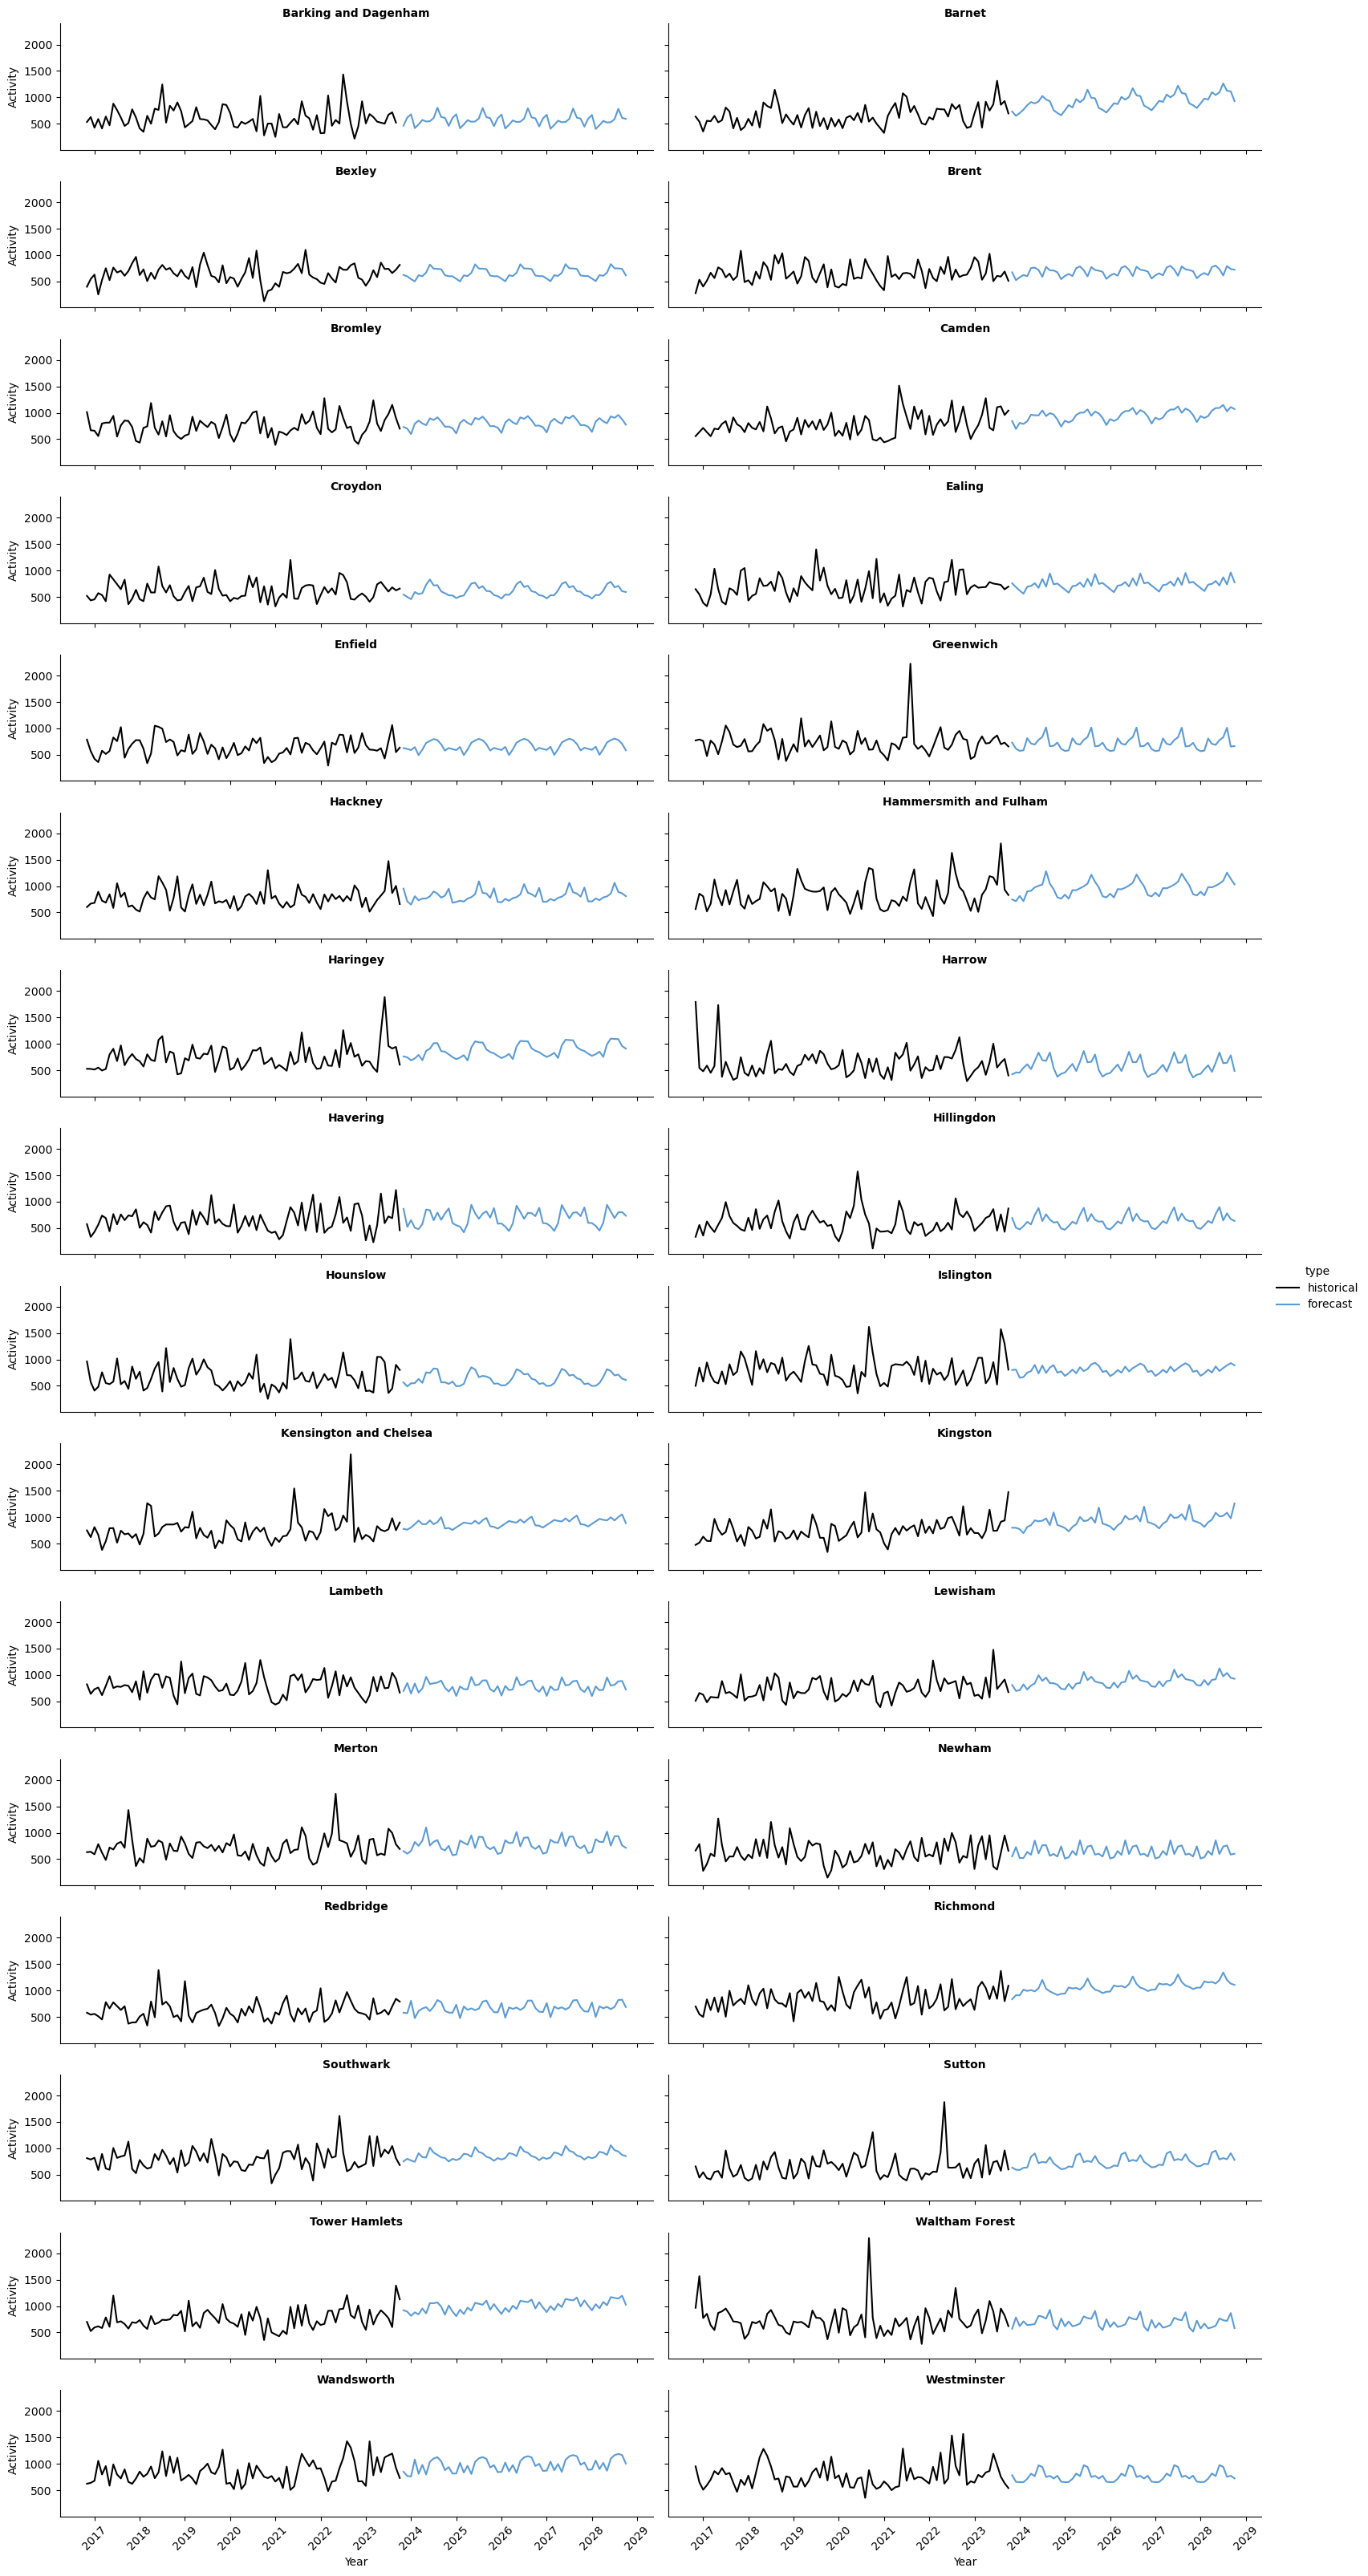

In [82]:
g = sns.relplot(kind='line', data=combined_df, x='t', y='y_pred', col='borough', col_wrap=2, height=2, aspect=4, hue='type', palette={'historical': 'black', 'forecast': '#5B9BD5'})
for borough, ax in g.axes_dict.items():
    borough_forecast = combined_df[combined_df['borough'] == borough]
    ax.errorbar(x=borough_forecast['t'], y=borough_forecast['y_pred'], yerr=borough_forecast['y_std'], fmt='none', alpha=0.3)
g.set(xticks=[2, 14, 26, 38, 50, 62, 74, 86, 98, 110, 122, 134, 146])
for ax in g.axes.flat: ax.set_xticklabels(['2017','2018','2019','2020','2021','2022','2023','2024','2025', '2026', '2027', '2028', '2029'], rotation=45)
g.set_titles('{col_name}', weight='bold')
g.set(xlabel='Year', ylabel='Activity')
plt.show()

In [83]:
for r in results:
    if len(r[2]) == 0: continue
    mape = np.mean(abs(r[2].values - r[1][:12]) / r[2].values) * 100
    print(r[0], mape)